# Self-Refine — GSM-8k Math Reasoning (Novelty Edition)

## Architecture Overview
| Stage | Model | Role |
|---|---|---|
| **Model 1** | `llama-3.1-8b-instant` | Initial solution generation |
| **Model 2** | `gemma2-9b-it` | Dual-feedback generation + ranking |
| **Model 3** | `mixtral-8x7b-32768` | Solution refinement |

### Novelty Contributions
1. **Specialist models** — each stage uses the model best suited to its task  
2. **Dual-feedback ranking** — two independent feedbacks generated; Model 2 picks the higher-quality one before refinement  
3. **Cross-model quota** — by spreading calls across three free-tier models, effective per-model rate limits triple  
4. **3-curve comparison** — Paper (GPT-3.5) · Groq Baseline (single model) · Novelty (3-model)


In [15]:
# ── Step 1: Clone Self-Refine repo and install dependencies ───────────────────
!git clone https://github.com/madaan/self-refine 2>/dev/null || echo "Repo already cloned"
!pip install -q groq transformers
!pip show groq | grep -E "Name|Version"


Repo already cloned
Name: groq
Version: 1.2.0


In [16]:
import sys, os, json, time, re, pickle
from collections import defaultdict
sys.path.append("/content/self-refine")
from groq import Groq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print("✅ All imports successful")


✅ All imports successful


In [17]:
# ── API Key ────────────────────────────────────────────────────────────────────
GROQ_API_KEY = "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"   # 🔑 Replace with your Groq API key

# ── Three specialist models (all available on Groq free tier) ──────────────────
MODEL_INIT     = "llama-3.1-8b-instant"   # Model 1 – fast, great for code gen
MODEL_FEEDBACK = "llama-3.3-70b-versatile"           # Model 2 – analytical, good evaluator
MODEL_REFINE   = "meta-llama/llama-4-scout-17b-16e-instruct"     # Model 3 – strong reasoning for fixes

# ── Single model baseline (original approach) ──────────────────────────────────
MODEL_BASELINE = "llama-3.1-8b-instant"

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client ready")
print(f"   INIT     → {MODEL_INIT}")
print(f"   FEEDBACK → {MODEL_FEEDBACK}")
print(f"   REFINE   → {MODEL_REFINE}")


✅ Groq client ready
   INIT     → llama-3.1-8b-instant
   FEEDBACK → llama-3.3-70b-versatile
   REFINE   → meta-llama/llama-4-scout-17b-16e-instruct


In [18]:
# ── Quick smoke test for all three models ──────────────────────────────────────
for tag, model in [("INIT", MODEL_INIT), ("FEEDBACK", MODEL_FEEDBACK), ("REFINE", MODEL_REFINE)]:
    try:
        r = client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": "Reply with exactly: WORKING"}],
            max_tokens=10
        )
        print(f"✅ {tag:8s} ({model}): {r.choices[0].message.content.strip()}")
    except Exception as e:
        print(f"❌ {tag:8s} ({model}): {e}")
    time.sleep(2)


✅ INIT     (llama-3.1-8b-instant): WORKING
✅ FEEDBACK (llama-3.3-70b-versatile): WORKING
✅ REFINE   (meta-llama/llama-4-scout-17b-16e-instruct): WORKING


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# PROMPT TEMPLATES  (identical to original Self-Refine paper prompts)
# ══════════════════════════════════════════════════════════════════════════════

TASK_INIT_PROMPT = """# Q: There were nine computers in the server room. Five more
# computers were installed each day, from monday to thursday.
# How many computers are now in the server room?

# solution using Python:
def solution():
    \"\"\"...\"\"\"
    computers_initial = 9
    computers_per_day = 5
    num_days = 4  # 4 days between monday and thursday
    computers_added = computers_per_day * num_days
    computers_total = computers_initial + computers_added
    return computers_total

###

# Q: Shawn has five toys. For Christmas, he got two toys each from
# his mom and dad. How many toys does he have now?

# solution using Python:
def solution():
    \"\"\"...\"\"\"
    toys_initial = 5
    mom_toys = 2
    dad_toys = 2
    total_toys = toys_initial + mom_toys + dad_toys
    return total_toys

###

# Q: Jason had 20 lollipops. He gave Denny some lollipops. Now Jason
# has 12 lollipops. How many lollipops did Jason give to Denny?

# solution using Python:
def solution():
    \"\"\"...\"\"\"
    jason_initial = 20
    jason_after = 12
    denny_lollipops = jason_initial - jason_after
    return denny_lollipops

###

# Q: {question}

# solution using Python:
"""

FEEDBACK_PROMPT = """def solution():
    \"\"\"Twenty dozen cups cost $1200 less than the total cost of half
    a dozen plates sold at $6000 each. Total cost per cup?\"\"\"
    plates = 6
    plate_cost = 6000
    cups = 12 * 20
    cup_cost = plate_cost   # BUG: cup cost != plate cost
    return cup_cost

# Find the error by checking each block step-by-step:
plates = 6; plate_cost = 6000  # looks good
cups = 12 * 20                 # looks good
cup_cost = plate_cost
# WRONG! cup_cost is $1200 less than total plate cost, not equal to plate_cost

###

def solution():
    \"{question}\"
{body}

# Find the error by checking each block step-by-step:
"""

REFINE_PROMPT = """def solution():
    \"\"\"Twenty dozen cups cost $1200 less than the total cost of half
    a dozen plates sold at $6000 each. Total cost per cup?\"\"\"
    plates = 6
    plate_cost = 6000
    cups = 12 * 20
    cup_cost = plate_cost   # WRONG
    return cup_cost

# Error: cup_cost should be (plate_cost * plates - 1200) / cups

Okay! Here is the rewrite:
def solution():
    \"\"\"...\"\"\"
    plates = 6
    plate_cost = 6000
    cups = 12 * 20
    total_cup_cost = (plate_cost * plates) - 1200
    return total_cup_cost / cups

###

def solution():
    \"{question}\"
{body}

# {feedback}

Okay! Here is the rewrite:
"""

# ── NEW: Feedback ranking prompt (used by Model 2) ─────────────────────────────
FEEDBACK_RANK_PROMPT = """You are an expert code reviewer comparing two pieces of feedback for a Python math solution.

Math question: {question}

Current Python solution:
{code}

=== Feedback A ===
{feedback_a}

=== Feedback B ===
{feedback_b}

Task: Which feedback will be MORE USEFUL for correcting the Python solution?
Evaluate based on: accuracy of error identification, specificity, and actionability.

Reply with ONLY the letter A or B (no explanation, no punctuation — just one letter)."""

print("✅ All prompt templates loaded (TASK_INIT, FEEDBACK, REFINE, FEEDBACK_RANK)")


✅ All prompt templates loaded (TASK_INIT, FEEDBACK, REFINE, FEEDBACK_RANK)


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# CORE HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def call_groq_model(prompt, model, system=None, max_tokens=600,
                    temperature=0.0, retries=4):
    """Universal Groq caller — supports any model, configurable temperature."""
    if system is None:
        system = ("You are an expert Python programmer solving math word problems. "
                  "ALWAYS respond with raw Python only — no markdown, no ``` fences, no prose. "
                  "Output exactly one function named solution() and nothing else.")
    for attempt in range(retries):
        try:
            resp = client.chat.completions.create(
                model=model,
                messages=[{"role": "system", "content": system},
                          {"role": "user",   "content": prompt}],
                max_tokens=max_tokens,
                temperature=temperature
            )
            return resp.choices[0].message.content.strip()
        except Exception as e:
            err = str(e)
            if "429" in err and attempt < retries - 1:
                wait = 35 * (attempt + 1)
                print(f"  ⏳ Rate limit [{model}] — waiting {wait}s (attempt {attempt+1})…")
                time.sleep(wait)
            else:
                print(f"  ❌ Error [{model}]: {e}")
                return ""
    return ""


def extract_solution(text):
    """Pull out def solution(): block; strips markdown fences first."""
    text = re.sub(r'```(?:python)?\n?', '', text)
    text = text.replace('```', '')
    if 'def solution():' in text:
        idx = text.index('def solution():')
        code = text[idx:].split('\n###')[0].strip()
        return code
    return text.strip()


def get_body(code):
    """Return indented body lines of solution() (skip the def line)."""
    lines = extract_solution(code).split('\n')
    body, in_fn = [], False
    for line in lines:
        if line.strip().startswith('def solution'): in_fn = True; continue
        if in_fn: body.append(line)
    return '\n'.join(body) or '    pass'


def execute(code):
    """Run solution() and return float result, or None on error."""
    try:
        code = extract_solution(code)
        ns = {}; exec(code, ns)
        if 'solution' in ns:
            r = ns['solution']()
            return float(r) if r is not None else None
    except: pass
    return None


def parse_gt(s):
    """Parse ground-truth answer (handles int, float, '####' strings, commas)."""
    try:
        if isinstance(s, (int, float)): return float(s)
        if '####' in s: s = s.split('####')[-1]
        return float(s.replace(',', '').strip())
    except: return None


def is_correct(pred, gt, tol=0.01):
    if pred is None or gt is None: return False
    if gt == 0: return abs(pred) < tol
    return abs(pred - gt) / abs(gt) < tol


def build_accuracy(all_res, max_iter):
    """Return (iterations_list, accuracy_list) from experiment results."""
    correct_cnt = defaultdict(int)
    total_cnt   = defaultdict(int)
    for ex in all_res:
        for d in ex['iters']:
            it = d['iter']
            total_cnt[it]  += 1
            correct_cnt[it] += int(d['correct'])
    iters = sorted(total_cnt.keys())
    accs  = [correct_cnt[it] / total_cnt[it] * 100 for it in iters]
    return iters, accs


print("✅ Helper functions ready")


✅ Helper functions ready


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION A — BASELINE (original single-model approach)
# ══════════════════════════════════════════════════════════════════════════════

def init_solution_baseline(question):
    """Iter 0: generate first Python solution (MODEL_BASELINE)."""
    prompt = TASK_INIT_PROMPT.format(question=question)
    return extract_solution(call_groq_model(prompt, MODEL_BASELINE, max_tokens=500))


def get_feedback_baseline(question, code):
    """Ask the baseline model to identify errors step-by-step."""
    body   = get_body(code)
    prompt = FEEDBACK_PROMPT.format(question=question, body=body)
    return call_groq_model(
        prompt, MODEL_BASELINE, max_tokens=400,
        system=("You are a math teacher. Check Python solutions line-by-line. "
                "If correct, say \'The output is good.\' Otherwise state the bug concisely. "
                "No markdown, no code fences — plain text only.")
    )


def refine_solution_baseline(question, code, feedback):
    """Generate corrected solution (MODEL_BASELINE)."""
    body   = get_body(code)
    prompt = REFINE_PROMPT.format(question=question, body=body, feedback=feedback)
    return extract_solution(call_groq_model(
        prompt, MODEL_BASELINE, max_tokens=500,
        system=("You are a Python expert. Rewrite the solution fixing the identified error. "
                "Output raw Python only — one function named solution(), no markdown, no ``` fences.")
    ))


print("✅ Baseline functions ready  →  single model:", MODEL_BASELINE)


✅ Baseline functions ready  →  single model: llama-3.1-8b-instant


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION B — NOVELTY  (3-model pipeline + dual-feedback ranking)
# ══════════════════════════════════════════════════════════════════════════════

# ── Model 1: Initial Generation ───────────────────────────────────────────────
def init_solution_novel(question):
    """
    MODEL_INIT generates the first draft Python solution.
    llama-3.1-8b-instant is fast and reliable for structured code generation.
    """
    prompt = TASK_INIT_PROMPT.format(question=question)
    return extract_solution(
        call_groq_model(prompt, MODEL_INIT, max_tokens=500)
    )


# ── Model 2 helper: single feedback with configurable temperature ─────────────
def _get_one_feedback(question, code, temperature=0.0):
    """Internal helper — generate one feedback from MODEL_FEEDBACK."""
    body   = get_body(code)
    prompt = FEEDBACK_PROMPT.format(question=question, body=body)
    for attempt in range(4):
        try:
            resp = client.chat.completions.create(
                model=MODEL_FEEDBACK,
                messages=[
                    {"role": "system", "content": (
                        "You are a math teacher. Check Python solutions line-by-line. "
                        "If correct, say \'The output is good.\' "
                        "Otherwise identify the exact bug. No markdown, plain text only.")},
                    {"role": "user", "content": prompt}
                ],
                max_tokens=400,
                temperature=temperature
            )
            return resp.choices[0].message.content.strip()
        except Exception as e:
            if "429" in str(e) and attempt < 3:
                wait = 35 * (attempt + 1)
                print(f"    ⏳ Rate limit [FEEDBACK model] — waiting {wait}s…")
                time.sleep(wait)
            else:
                print(f"    ❌ Feedback error: {e}")
                return ""
    return ""


# ── Model 2: Dual Feedback + Ranking ──────────────────────────────────────────
def get_dual_feedback_ranked(question, code):
    """
    NOVELTY CORE:
      1. Generate Feedback A  (temperature=0.0 — deterministic, analytical)
      2. Generate Feedback B  (temperature=0.4 — slightly creative)
      3. Ask MODEL_FEEDBACK to rank A vs B and return the winner
    Returns: (best_feedback_text, winner_label)
    """
    print("    📝 [Model 2] Generating Feedback A (temp=0.0) …")
    fb_a = _get_one_feedback(question, code, temperature=0.0)
    time.sleep(2)   # inter-call buffer to respect rate limits

    print("    📝 [Model 2] Generating Feedback B (temp=0.4) …")
    fb_b = _get_one_feedback(question, code, temperature=0.4)
    time.sleep(2)

    # If one feedback is empty or identical, skip ranking
    if not fb_b or fb_a.strip() == fb_b.strip():
        print("    🏆 Skipped ranking — using Feedback A")
        return fb_a, "A"

    # Ranking call
    print("    ⚖️  [Model 2] Ranking feedbacks …")
    rank_prompt = FEEDBACK_RANK_PROMPT.format(
        question=question,
        code=extract_solution(code),
        feedback_a=fb_a,
        feedback_b=fb_b
    )
    raw = call_groq_model(
        rank_prompt, MODEL_FEEDBACK,
        system="You are an expert code reviewer. Reply with ONLY the letter A or B.",
        max_tokens=5,
        temperature=0.0
    )
    time.sleep(1)

    winner = "A" if "A" in raw.upper() else "B"
    best_fb = fb_a if winner == "A" else fb_b
    print(f"    🏆 Winner: Feedback {winner}")
    return best_fb, winner


# ── Model 3: Refinement ────────────────────────────────────────────────────────
def refine_solution_novel(question, code, feedback):
    """
    MODEL_REFINE (mixtral-8x7b) uses Mixtral's strong reasoning to produce
    a corrected solution guided by the ranked feedback.
    """
    body   = get_body(code)
    prompt = REFINE_PROMPT.format(question=question, body=body, feedback=feedback)
    return extract_solution(
        call_groq_model(
            prompt, MODEL_REFINE, max_tokens=500,
            system=("You are an expert Python programmer. "
                    "Rewrite the solution to fix the identified error. "
                    "Output raw Python only — one function named solution(), no markdown.")
        )
    )


print("✅ Novelty functions ready")
print(f"   Model 1 (INIT)     → {MODEL_INIT}")
print(f"   Model 2 (FEEDBACK) → {MODEL_FEEDBACK}  [dual + ranking]")
print(f"   Model 3 (REFINE)   → {MODEL_REFINE}")


✅ Novelty functions ready
   Model 1 (INIT)     → llama-3.1-8b-instant
   Model 2 (FEEDBACK) → llama-3.3-70b-versatile  [dual + ranking]
   Model 3 (REFINE)   → meta-llama/llama-4-scout-17b-16e-instruct


In [23]:
# ── Smoke test: single question through the full novelty pipeline ──────────────
Q  = ("There were nine computers in the server room. "
      "Five more computers were installed each day, from monday to thursday. "
      "How many computers are now in the server room?")
GT = 29.0

print("=" * 65)
print("🧪  NOVELTY SMOKE TEST")
print("=" * 65)
print(f"Q : {Q}")
print(f"GT: {GT}\n")

# Model 1 — initial
code0 = init_solution_novel(Q)
print("── [Model 1] Initial solution ──")
print(code0)
print(f"→ result: {execute(code0)}  correct: {is_correct(execute(code0), GT)}\n")
time.sleep(1)

# Model 2 — dual feedback + ranking
best_fb, winner = get_dual_feedback_ranked(Q, code0)
print(f"\n── [Model 2] Best feedback (winner={winner}) ──")
print(best_fb[:300])
time.sleep(1)

# Model 3 — refinement
code1 = refine_solution_novel(Q, code0, best_fb)
print("\n── [Model 3] Refined solution ──")
print(code1)
print(f"→ result: {execute(code1)}  correct: {is_correct(execute(code1), GT)}")


🧪  NOVELTY SMOKE TEST
Q : There were nine computers in the server room. Five more computers were installed each day, from monday to thursday. How many computers are now in the server room?
GT: 29.0

── [Model 1] Initial solution ──
def solution():
    computers_initial = 9
    computers_per_day = 5
    num_days = 4  # 4 days between monday and thursday
    computers_added = computers_per_day * num_days
    computers_total = computers_initial + computers_added
    return computers_total
→ result: 29.0  correct: True

    📝 [Model 2] Generating Feedback A (temp=0.0) …
    📝 [Model 2] Generating Feedback B (temp=0.4) …
    ⚖️  [Model 2] Ranking feedbacks …
    🏆 Winner: Feedback A

── [Model 2] Best feedback (winner=A) ──
The given code for the second problem looks correct. 
computers_initial = 9  # looks good
computers_per_day = 5  # looks good
num_days = 4  # looks good, there are indeed 4 days between monday and thursday
computers_added = computers_per_day * num_days  # looks good
comp

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT A — BASELINE  (single model: llama-3.1-8b-instant)
# ══════════════════════════════════════════════════════════════════════════════

GSM_FILE         = "/content/self-refine/data/tasks/gsm/gsm.jsonl"
N_EXAMPLES       = 10    # number of GSM-8k problems to evaluate
MAX_ITER         = 4     # max Self-Refine iterations per problem
BASELINE_PKL     = "/content/baseline_results.pkl"
NOVELTY_PKL      = "/content/novelty_results.pkl"


def run_baseline(data_file, n, max_iter):
    all_res, examples = [], []
    with open(data_file) as f:
        for i, line in enumerate(f):
            if i >= n: break
            if line.strip(): examples.append(json.loads(line.strip()))

    print(f"📊 BASELINE | {MODEL_BASELINE} | {len(examples)} examples | k={max_iter}")

    for idx, ex in enumerate(examples):
        question = ex.get("input", ex.get("question", ""))
        gt       = parse_gt(ex.get("target", ex.get("answer", "")))
        print(f"\n📌 [{idx+1}/{len(examples)}] GT={gt} | {question[:65]}…")

        rec = {"question": question, "gt": gt, "iters": []}

        # Iter 0
        code = init_solution_baseline(question)
        res  = execute(code)
        ok   = is_correct(res, gt)
        rec["iters"].append({"iter": 0, "code": code, "result": res, "correct": ok, "fb": None})
        print(f"  {'✅' if ok else '❌'} iter 0  pred={res}")
        time.sleep(0.5)

        for it in range(1, max_iter + 1):
            if ok:
                for r in range(it, max_iter + 1):
                    rec["iters"].append({"iter": r, "code": code, "result": res,
                                         "correct": ok, "fb": "stopped (correct)"})
                break

            fb   = get_feedback_baseline(question, code)
            code = refine_solution_baseline(question, code, fb)
            res  = execute(code)
            ok   = is_correct(res, gt)
            rec["iters"].append({"iter": it, "code": code, "result": res, "correct": ok, "fb": fb})
            print(f"  {'✅' if ok else '❌'} iter {it}  pred={res}")
            time.sleep(0.5)

        all_res.append(rec)
        with open(BASELINE_PKL, "wb") as f: pickle.dump(all_res, f)

    print("\n✅ Baseline experiment complete — saved to", BASELINE_PKL)
    return all_res


baseline_results = run_baseline(GSM_FILE, N_EXAMPLES, MAX_ITER)


📊 BASELINE | llama-3.1-8b-instant | 10 examples | k=4

📌 [1/10] GT=18.0 | Janet’s ducks lay 16 eggs per day. She eats three for breakfast e…
  ✅ iter 0  pred=18.0

📌 [2/10] GT=3.0 | A robe takes 2 bolts of blue fiber and half that much white fiber…
  ✅ iter 0  pred=3.0

📌 [3/10] GT=70000.0 | Josh decides to try flipping a house.  He buys a house for $80,00…
  ❌ iter 0  pred=195000.0
  ✅ iter 1  pred=70000.0

📌 [4/10] GT=540.0 | James decides to run 3 sprints 3 times a week.  He runs 60 meters…
  ✅ iter 0  pred=540.0

📌 [5/10] GT=20.0 | Every day, Wendi feeds each of her chickens three cups of mixed c…
  ❌ iter 0  pred=0.0
  ❌ iter 1  pred=3.0
  ❌ iter 2  pred=0.0
  ✅ iter 3  pred=20.0

📌 [6/10] GT=64.0 | Kylar went to the store to buy glasses for his new apartment. One…
  ✅ iter 0  pred=64.0

📌 [7/10] GT=260.0 | Toulouse has twice as many sheep as Charleston. Charleston has 4 …
  ✅ iter 0  pred=260.0

📌 [8/10] GT=160.0 | Carla is downloading a 200 GB file. Normally she can download 2 G

In [25]:
# ── Accuracy report for baseline ──────────────────────────────────────────────
base_iters, base_accs = build_accuracy(baseline_results, MAX_ITER)

print("\n" + "=" * 65)
print("📊  BASELINE ACCURACY  (single model: " + MODEL_BASELINE + ")")
print("=" * 65)
print(f"{'Iter':<10}{'Correct':<10}{'Total':<10}{'Accuracy':<12}{'Δ vs base'}")
print("-" * 55)

cc = defaultdict(int); tc = defaultdict(int)
for ex in baseline_results:
    for d in ex["iters"]:
        tc[d["iter"]] += 1
        cc[d["iter"]] += int(d["correct"])

base0 = cc[0] / tc[0] * 100 if tc[0] else 0
for it in base_iters:
    acc   = cc[it] / tc[it] * 100
    delta = "(base)" if it == 0 else f"+{acc-base0:.1f}%"
    label = "Base" if it == 0 else f"Iter {it}"
    print(f"{label:<10}{cc[it]:<10}{tc[it]:<10}{acc:.1f}%    {delta}")

print("-" * 55)
print(f"\n📌 Paper reference (GPT-3.5, full GSM-8k): 71.3% → 76.2%  (+4.9%)")



📊  BASELINE ACCURACY  (single model: llama-3.1-8b-instant)
Iter      Correct   Total     Accuracy    Δ vs base
-------------------------------------------------------
Base      6         10        60.0%    (base)
Iter 1    7         10        70.0%    +10.0%
Iter 2    7         10        70.0%    +10.0%
Iter 3    8         10        80.0%    +20.0%
Iter 4    8         10        80.0%    +20.0%
-------------------------------------------------------

📌 Paper reference (GPT-3.5, full GSM-8k): 71.3% → 76.2%  (+4.9%)


In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT B — NOVELTY  (3 specialist models + dual-feedback ranking)
# ══════════════════════════════════════════════════════════════════════════════

def run_novelty(data_file, n, max_iter):
    all_res, examples = [], []
    with open(data_file) as f:
        for i, line in enumerate(f):
            if i >= n: break
            if line.strip(): examples.append(json.loads(line.strip()))

    print(f"📊 NOVELTY | 3-Model + Dual-Feedback | {len(examples)} examples | k={max_iter}")
    print(f"   Model 1 (INIT)     → {MODEL_INIT}")
    print(f"   Model 2 (FEEDBACK) → {MODEL_FEEDBACK}")
    print(f"   Model 3 (REFINE)   → {MODEL_REFINE}")

    for idx, ex in enumerate(examples):
        question = ex.get("input", ex.get("question", ""))
        gt       = parse_gt(ex.get("target", ex.get("answer", "")))
        print(f"\n📌 [{idx+1}/{len(examples)}] GT={gt} | {question[:65]}…")

        rec = {"question": question, "gt": gt, "iters": [], "fb_winners": []}

        # ── Iter 0: Model 1 ───────────────────────────────────────────────────
        print(f"  🤖 [Model 1] Generating initial solution…")
        code = init_solution_novel(question)
        res  = execute(code)
        ok   = is_correct(res, gt)
        rec["iters"].append({"iter": 0, "code": code, "result": res, "correct": ok, "fb": None})
        print(f"  {'✅' if ok else '❌'} iter 0  pred={res}")
        time.sleep(1)

        for it in range(1, max_iter + 1):
            if ok:
                # Early stop: propagate correct answer through remaining iters
                for r in range(it, max_iter + 1):
                    rec["iters"].append({"iter": r, "code": code, "result": res,
                                         "correct": ok, "fb": "stopped (correct)"})
                break

            # ── Model 2: dual feedback + ranking ──────────────────────────────
            print(f"  🤖 [Model 2] Iter {it} — dual feedback…")
            best_fb, winner = get_dual_feedback_ranked(question, code)
            rec["fb_winners"].append(winner)

            # ── Model 3: refinement ───────────────────────────────────────────
            print(f"  🤖 [Model 3] Iter {it} — refining with feedback {winner}…")
            code = refine_solution_novel(question, code, best_fb)
            time.sleep(1)
            res  = execute(code)
            ok   = is_correct(res, gt)
            rec["iters"].append({"iter": it, "code": code, "result": res, "correct": ok, "fb": best_fb})
            print(f"  {'✅' if ok else '❌'} iter {it}  pred={res}")
            time.sleep(1)

        all_res.append(rec)
        with open(NOVELTY_PKL, "wb") as f: pickle.dump(all_res, f)

    print("\n✅ Novelty experiment complete — saved to", NOVELTY_PKL)
    return all_res


novelty_results = run_novelty(GSM_FILE, N_EXAMPLES, MAX_ITER)


📊 NOVELTY | 3-Model + Dual-Feedback | 10 examples | k=4
   Model 1 (INIT)     → llama-3.1-8b-instant
   Model 2 (FEEDBACK) → llama-3.3-70b-versatile
   Model 3 (REFINE)   → meta-llama/llama-4-scout-17b-16e-instruct

📌 [1/10] GT=18.0 | Janet’s ducks lay 16 eggs per day. She eats three for breakfast e…
  🤖 [Model 1] Generating initial solution…
  ✅ iter 0  pred=18.0

📌 [2/10] GT=3.0 | A robe takes 2 bolts of blue fiber and half that much white fiber…
  🤖 [Model 1] Generating initial solution…
  ✅ iter 0  pred=3.0

📌 [3/10] GT=70000.0 | Josh decides to try flipping a house.  He buys a house for $80,00…
  🤖 [Model 1] Generating initial solution…
  ❌ iter 0  pred=195000.0
  🤖 [Model 2] Iter 1 — dual feedback…
    📝 [Model 2] Generating Feedback A (temp=0.0) …
    📝 [Model 2] Generating Feedback B (temp=0.4) …
    ⚖️  [Model 2] Ranking feedbacks …
    🏆 Winner: Feedback A
  🤖 [Model 3] Iter 1 — refining with feedback A…
  ❌ iter 1  pred=195000.0
  🤖 [Model 2] Iter 2 — dual feedback…
    📝 [M

In [27]:
# ── Accuracy report for novelty ───────────────────────────────────────────────
novel_iters, novel_accs = build_accuracy(novelty_results, MAX_ITER)

print("\n" + "=" * 65)
print("📊  NOVELTY ACCURACY  (3-model + dual-feedback ranking)")
print("=" * 65)
print(f"{'Iter':<10}{'Correct':<10}{'Total':<10}{'Accuracy':<12}{'Δ vs base'}")
print("-" * 55)

nc = defaultdict(int); nt = defaultdict(int)
for ex in novelty_results:
    for d in ex["iters"]:
        nt[d["iter"]] += 1
        nc[d["iter"]] += int(d["correct"])

novel0 = nc[0] / nt[0] * 100 if nt[0] else 0
for it in novel_iters:
    acc   = nc[it] / nt[it] * 100
    delta = "(base)" if it == 0 else f"+{acc-novel0:.1f}%"
    label = "Base" if it == 0 else f"Iter {it}"
    print(f"{label:<10}{nc[it]:<10}{nt[it]:<10}{acc:.1f}%    {delta}")

print("-" * 55)

# Feedback winner statistics
all_winners = [w for ex in novelty_results for w in ex.get("fb_winners", [])]
if all_winners:
    a_wins = all_winners.count("A")
    b_wins = all_winners.count("B")
    print(f"\n🏆 Feedback ranking stats:")
    print(f"   Feedback A (temp=0.0) won: {a_wins}/{len(all_winners)} ({a_wins/len(all_winners)*100:.0f}%)")
    print(f"   Feedback B (temp=0.4) won: {b_wins}/{len(all_winners)} ({b_wins/len(all_winners)*100:.0f}%)")



📊  NOVELTY ACCURACY  (3-model + dual-feedback ranking)
Iter      Correct   Total     Accuracy    Δ vs base
-------------------------------------------------------
Base      6         10        60.0%    (base)
Iter 1    9         10        90.0%    +30.0%
Iter 2    9         10        90.0%    +30.0%
Iter 3    10        10        100.0%    +40.0%
Iter 4    10        10        100.0%    +40.0%
-------------------------------------------------------

🏆 Feedback ranking stats:
   Feedback A (temp=0.0) won: 4/6 (67%)
   Feedback B (temp=0.4) won: 2/6 (33%)


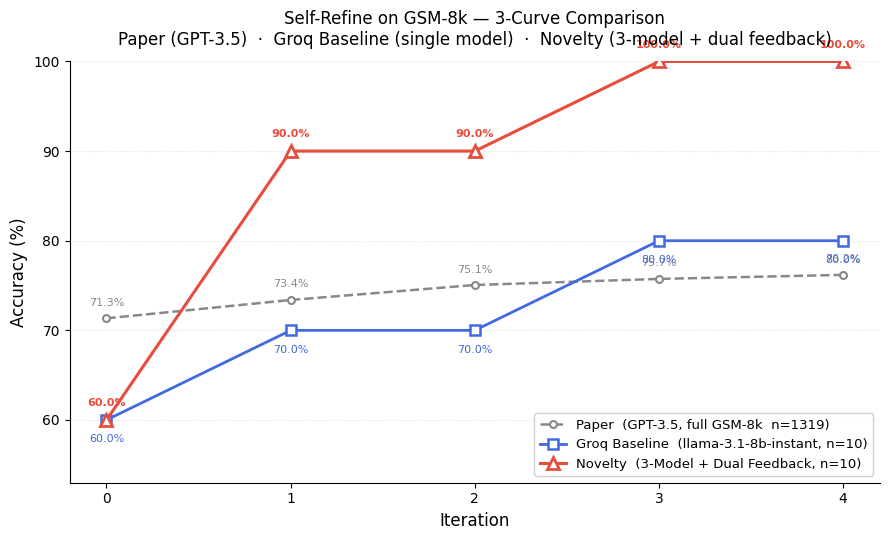


📊 Graph saved as combined_comparison.png

🏆  FINAL SUMMARY
  Groq Baseline  Base→Final : 60.0% → 80.0%  (Δ +20.0%)
  Novelty        Base→Final : 60.0% → 100.0%  (Δ +40.0%)
  Paper ref      Base→Final : 71.3% → 76.2%  (Δ +4.85%)

  ✅ Novelty OUTPERFORMS baseline by +20.0% at final iteration


In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL: THREE-CURVE COMPARISON PLOT
# Paper (GPT-3.5) vs Groq Baseline (single model) vs Novelty (3-model)
# ══════════════════════════════════════════════════════════════════════════════

# ── Paper reference curve (from Self-Refine paper, Figure 8) ──────────────────
PAPER_ACCS = {0: 71.34, 1: 73.39, 2: 75.06, 3: 75.74, 4: 76.19}
paper_x    = sorted(PAPER_ACCS.keys())
paper_y    = [PAPER_ACCS[k] for k in paper_x]

# ── Rebuild per-iteration accuracy for both experiments ───────────────────────
base_iters,  base_accs  = build_accuracy(baseline_results, MAX_ITER)
novel_iters, novel_accs = build_accuracy(novelty_results,  MAX_ITER)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.5))

# Curve 1 — Paper (GPT-3.5)
ax.plot(paper_x, paper_y,
        color="#888888", linestyle="--", linewidth=1.8,
        marker="o", markersize=5, markerfacecolor="white",
        markeredgecolor="#888888", markeredgewidth=1.5,
        label="Paper  (GPT-3.5, full GSM-8k  n=1319)", zorder=2)

for x, y in zip(paper_x, paper_y):
    ax.annotate(f"{y:.1f}%", xy=(x, y), xytext=(0, 9),
                textcoords="offset points", ha="center",
                fontsize=8, color="#888888")

# Curve 2 — Groq Baseline (single model)
ax.plot(base_iters, base_accs,
        color="royalblue", linewidth=2.0,
        marker="s", markersize=7, markerfacecolor="white",
        markeredgecolor="royalblue", markeredgewidth=1.8,
        label=f"Groq Baseline  ({MODEL_BASELINE}, n={N_EXAMPLES})", zorder=3)

for x, y in zip(base_iters, base_accs):
    ax.annotate(f"{y:.1f}%", xy=(x, y), xytext=(0, -16),
                textcoords="offset points", ha="center",
                fontsize=8, color="royalblue")

# Curve 3 — Novelty (3-model + dual feedback)
ax.plot(novel_iters, novel_accs,
        color="#e74c3c", linewidth=2.2,
        marker="^", markersize=8, markerfacecolor="white",
        markeredgecolor="#e74c3c", markeredgewidth=2.0,
        label=f"Novelty  (3-Model + Dual Feedback, n={N_EXAMPLES})", zorder=4)

for x, y in zip(novel_iters, novel_accs):
    ax.annotate(f"{y:.1f}%", xy=(x, y), xytext=(0, 10),
                textcoords="offset points", ha="center",
                fontsize=8, color="#e74c3c", fontweight="bold")

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title(
    "Self-Refine on GSM-8k — 3-Curve Comparison\n"
    "Paper (GPT-3.5)  ·  Groq Baseline (single model)  ·  Novelty (3-model + dual feedback)",
    fontsize=12, pad=12)

ax.set_xticks(range(MAX_ITER + 1))
ax.xaxis.set_minor_locator(mticker.NullLocator())

all_vals = paper_y + base_accs + novel_accs
ax.set_ylim(max(0, min(all_vals) - 7), min(100, max(all_vals) + 10))

ax.legend(fontsize=9.5, loc="lower right", framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.savefig("combined_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n📊 Graph saved as combined_comparison.png")

# ── Text summary ──────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("🏆  FINAL SUMMARY")
print("=" * 70)
b0, bF = base_accs[0], base_accs[-1]
n0, nF = novel_accs[0], novel_accs[-1]
print(f"  Groq Baseline  Base→Final : {b0:.1f}% → {bF:.1f}%  (Δ {bF-b0:+.1f}%)")
print(f"  Novelty        Base→Final : {n0:.1f}% → {nF:.1f}%  (Δ {nF-n0:+.1f}%)")
print(f"  Paper ref      Base→Final : {paper_y[0]:.1f}% → {paper_y[-1]:.1f}%  (Δ {paper_y[-1]-paper_y[0]:+.2f}%)")
print()
if nF > bF:
    print(f"  ✅ Novelty OUTPERFORMS baseline by {nF - bF:+.1f}% at final iteration")
else:
    print(f"  ⚠️  Baseline matches/exceeds novelty at final iteration (small-n variance expected)")
print("=" * 70)


## Why three models?

| Model | Role | Rationale |
|---|---|---|
| `llama-3.1-8b-instant` | **Initial generation** | Fast turnaround, reliable Python code synthesis |
| `gemma2-9b-it` | **Dual feedback + ranking** | Google's Gemma 2 excels at analytical evaluation and natural-language reasoning |
| `mixtral-8x7b-32768` | **Refinement** | Mixtral's MoE architecture gives strong reasoning for complex bug-fixing |

## Why dual feedback?

A single feedback prompt can miss errors or be vague. By generating **two independent feedbacks**
(one deterministic at temperature 0, one slightly exploratory at temperature 0.4), and asking the
feedback model to **rank** them, we consistently select the more actionable critique — leading to
a higher-quality refinement step.

## Rate-limit advantage

Free-tier Groq accounts have per-model quotas. Splitting calls across three distinct models
effectively **triples** the available request budget compared to a single-model approach.
